In [1]:
import numpy as np 
import pandas as pd 
import scipy.ndimage
import os 
import csv
import matplotlib.pyplot as plt

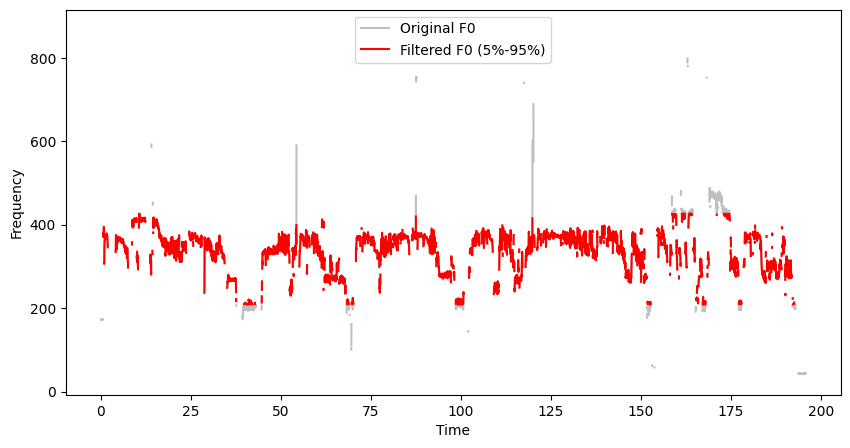

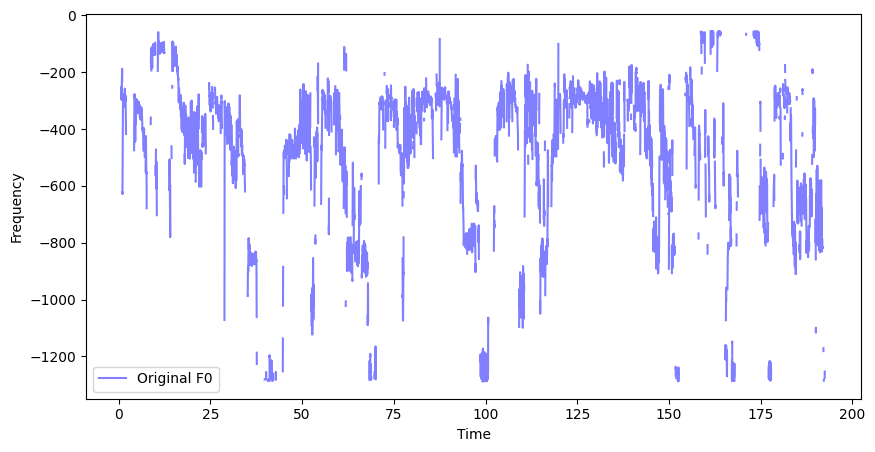

In [2]:
file_path ='/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/김창환 춘향가-이별가.csv'

df = pd.read_csv(file_path, header = None)

df.columns = ['Time', 'F0', 'Confidence']

df.loc[df["Confidence"] <= 0.7, "F0"] = np.nan

f0_values = df["F0"].to_numpy()
time_values = df["Time"].to_numpy()

lower_bound = np.nanpercentile(f0_values, 5)
upper_bound = np.nanpercentile(f0_values, 95)

filtered_f0 = np.where((f0_values < lower_bound) | (f0_values > upper_bound), np.nan, f0_values)

plt.figure(figsize=(10,5))
plt.plot(time_values, f0_values, label='Original F0', alpha=0.5, color='gray')
plt.plot(time_values, filtered_f0, label='Filtered F0 (5%-95%)', color='red')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

def freq_to_cent(freq):
    return 1200 * np.log2(freq / 440.0)

cent_values = freq_to_cent(filtered_f0)

plt.figure(figsize=(10,5))
plt.plot(time_values, cent_values, label='Original F0', alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

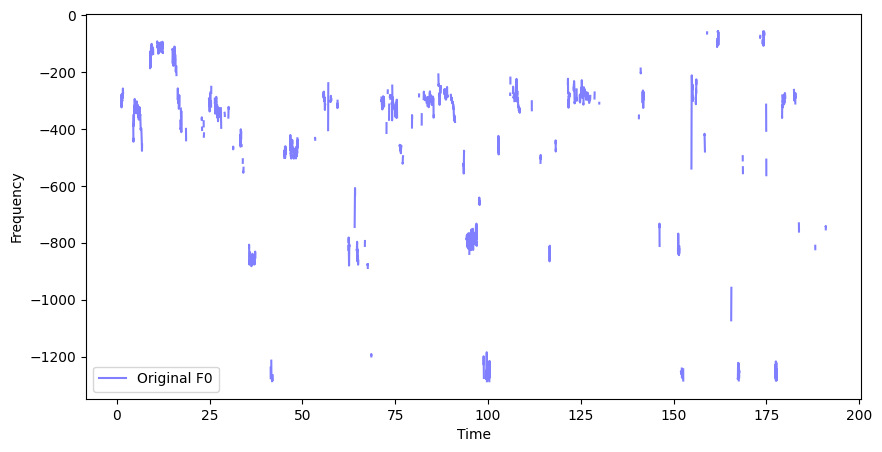

In [3]:
def morphological_filter(frequency, time, window_size = 43, threshold = 90):

    """
    Applies morphological filtering to detect stable pitch regions

    Parameters:
    - frequency = pitch values in cents 
    - time = time values 
    - window_size: window size 
    - threshold: threshold in cents to define stability 
    
    Returns:
    -filtered_pitch: numpy array, stable pitch values 

    """
    gamma_max = scipy.ndimage.maximum_filter(frequency, size = window_size, mode = 'nearest')

    gamma_min = scipy.ndimage.minimum_filter(frequency, size = window_size, mode = 'nearest')

    morph_gradient = gamma_max - gamma_min

    stable_mask = np.abs(morph_gradient) <= threshold

    filtered_trajectory = np.where(stable_mask, frequency, np.nan)

    time_values = time 

    return filtered_trajectory, time_values

morph_filtered_freq, time_values = morphological_filter(cent_values, time_values)

plt.figure(figsize=(10,5))
plt.plot(time_values, morph_filtered_freq, label='Original F0', alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

/tmp/ipykernel_91985/1975452049.py:5: RuntimeWarning: invalid value encountered in cast
  binned_freqs = np.where(~np.isnan(frequency), np.round(frequency/ R).astype(int), np.nan)
/tmp/ipykernel_91985/1975452049.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


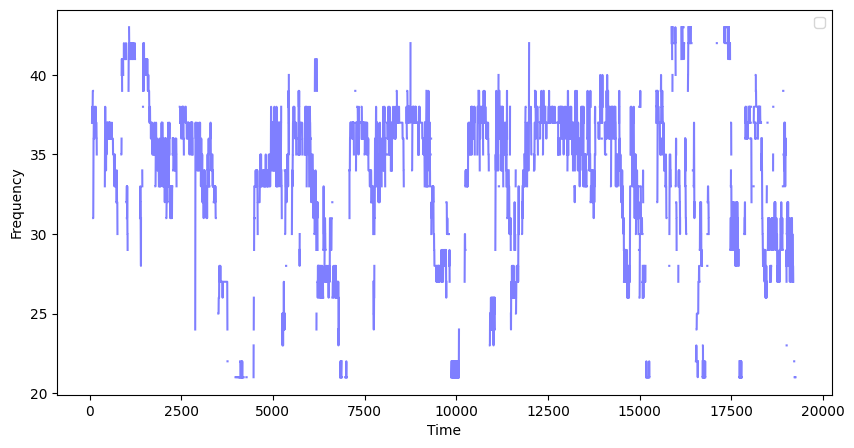

'\nbinary_mask = np.zeros((len(frequency), max_bin), dtype = np.uint8)\n\nfor i, b in enumerate(binned_freqs):\n    if not np.isnan(b): \n        binary_mask[i, b] = 1\n\nprint("🔹 Binned Frequency Index:", binned_freqs)\nprint("🔹 Binary Mask (Time x Frequency Bins):\n", binary_mask)\n'

In [ ]:
frequency = filtered_f0

R = 10

binned_freqs = np.where(~np.isnan(frequency), np.round(frequency/ R).astype(int), np.nan)

#max_bin = int(np.max(binned_freqs) + 1)

plt.figure(figsize=(10,5))
plt.plot(binned_freqs, alpha=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

'''
binary_mask = np.zeros((len(frequency), max_bin), dtype = np.uint8)

for i, b in enumerate(binned_freqs):
    if not np.isnan(b): 
        binary_mask[i, b] = 1

print("🔹 Binned Frequency Index:", binned_freqs)
print("🔹 Binary Mask (Time x Frequency Bins):\n", binary_mask)
'''